# SVM Model

In [ ]:
import pandas as pd
df = pd.read_csv("music_data.csv")

In [ ]:
df.head()

,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre
0,Dead Prez,7gXuElmegVReY7imkb5bf8,Let's Get Free,90s Hiphop / Gangsta Rap,5yGuoOwRQF3o8NVRRlvCj7,gangster rap,0.725,0.737,4,-7.453,...,0.00417,0.109,0.219,77.161,214067,2HoDr1yVksl19omOhc1zWy,Hip-Hop,57,2000,Hip-Hop
1,Naughty By Nature,4OEP9VlZWOCt1QcOzX0oXF,19 Naughty III,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,southern hip hop,0.862,0.642,6,-13.652,...,0.00000,0.272,0.765,99.201,267267,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
2,Naughty By Nature,6smksVgwxaPFGdSsIloCjo,Anthem Inc.,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,new jack swing,0.776,0.968,4,-4.250,...,0.00000,0.204,0.667,97.765,250173,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
3,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,Dr. Q's Prescription Playlist💊,6jAPdgY9XmxC9cgkXAVmVv,post-teen pop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop
4,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,90s-2000s Southern Hip Hop / Crunk,5wsWBmQgDtKa8CEg7wTEMi,southern hip hop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop


In [ ]:
df.columns

Index(['track_artist', 'track_album_id', 'track_album_name', 'playlist_name',
       'playlist_id', 'playlist_subgenre', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'track_id', 'track_name',
       'track_popularity', 'release_year', 'genre'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_artist       6484 non-null   object 
 1   track_album_id     6484 non-null   object 
 2   track_album_name   6484 non-null   object 
 3   playlist_name      6484 non-null   object 
 4   playlist_id        6484 non-null   object 
 5   playlist_subgenre  6484 non-null   object 
 6   danceability       6484 non-null   float64
 7   energy             6484 non-null   float64
 8   key                6484 non-null   int64  
 9   loudness           6484 non-null   float64
 10  mode               6484 non-null   int64  
 11  speechiness        6484 non-null   float64
 12  acousticness       6484 non-null   float64
 13  instrumentalness   6484 non-null   float64
 14  liveness           6484 non-null   float64
 15  valence            6484 non-null   float64
 16  tempo              6484 

In [ ]:
# Remove duplicates
df = df.drop_duplicates()
df.size

149132

In [ ]:
df.isnull().sum()

,0
track_artist,0
track_album_id,0
track_album_name,0
playlist_name,0
playlist_id,0
playlist_subgenre,0
danceability,0
energy,0
key,0
loudness,0


In [ ]:
# Fill missing numeric values with median

df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity,release_year
count,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.00000,6484.000000,6484.000000
mean,0.656687,0.662695,5.108112,-6.339298,0.541487,0.116708,0.175291,0.028306,0.189283,0.461480,121.143942,225103.89343,60.130475,2013.432603
std,0.152863,0.175067,3.640679,2.571509,0.498314,0.108356,0.218181,0.122330,0.146737,0.220573,28.065763,54901.41406,18.761127,13.324169
min,0.135000,0.045500,0.000000,-23.459000,0.000000,0.023200,0.000015,0.000000,0.009360,0.034900,48.718000,37640.00000,0.000000,1958.000000
25%,0.555000,0.538000,1.000000,-7.621000,0.000000,0.043800,0.018900,0.000000,0.096900,0.293000,99.252000,191661.00000,53.000000,2012.000000
50%,0.671000,0.672000,5.000000,-5.884000,1.000000,0.065300,0.080450,0.000002,0.130000,0.440000,120.073000,216245.00000,63.000000,2018.000000
75%,0.771000,0.799000,8.000000,-4.559000,1.000000,0.153000,0.243000,0.000287,0.237000,0.619000,136.245000,248403.25000,72.000000,2022.000000
max,0.977000,0.998000,11.000000,-0.475000,1.000000,0.918000,0.984000,0.963000,0.984000,0.979000,207.969000,517125.00000,100.000000,2025.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=['object']).columns

# Create a LabelEncoder instance
le = LabelEncoder()

# Convert each object column to numeric using Label Encoding
for column in categorical_cols:
    df[column] = le.fit_transform(df[column])

In [ ]:
print("Data after cleaning:")
df.head()

Data after cleaning:


,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre
0,72,1789,783,23,294,6,0.725,0.737,4,-7.453,...,0.00417,0.109,0.219,77.161,214067,140,157,57,2000,12
1,197,1056,17,18,230,20,0.862,0.642,6,-13.652,...,0.00000,0.272,0.765,99.201,267267,88,148,66,1993,12
2,197,1651,104,35,192,14,0.776,0.968,4,-4.250,...,0.00000,0.204,0.667,97.765,250173,88,148,66,1993,12
3,48,750,1419,81,325,17,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,35,153,35,2007,12
4,48,750,1419,24,293,20,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,35,153,35,2007,12


# ML Modelling

In [ ]:
#Input

x = df.drop(['track_popularity','track_artist',	'track_album_id',	'track_album_name',	'playlist_name','playlist_id','playlist_subgenre','loudness'],axis=1)
x

,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,release_year,genre
0,0.725,0.737,4,1,0.3240,0.000633,0.004170,0.1090,0.219,77.161,214067,140,157,2000,12
1,0.862,0.642,6,0,0.1010,0.102000,0.000000,0.2720,0.765,99.201,267267,88,148,1993,12
2,0.776,0.968,4,0,0.0914,0.001470,0.000000,0.2040,0.667,97.765,250173,88,148,1993,12
3,0.788,0.798,8,0,0.0997,0.189000,0.000000,0.3000,0.836,143.051,303053,35,153,2007,12
4,0.788,0.798,8,0,0.0997,0.189000,0.000000,0.3000,0.836,143.051,303053,35,153,2007,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479,0.724,0.573,7,1,0.0549,0.118000,0.000000,0.5380,0.438,113.088,135920,434,170,2007,13
6480,0.901,0.522,2,1,0.3300,0.011400,0.000000,0.2590,0.329,104.053,127947,434,170,2007,13
6481,0.643,0.717,8,0,0.5060,0.184000,0.000000,0.1520,0.460,90.893,223507,434,170,2007,13
6482,0.529,0.900,1,1,0.4180,0.000248,0.000012,0.0426,0.434,180.291,104591,434,170,2007,13


In [ ]:
# Output

# 1 -> Popular
# 0 -> Not Popular

y = (df['track_popularity'] >= 50).astype(int)
y

,track_popularity
0,1
1,1
2,1
3,0
4,0
...,...
6479,1
6480,1
6481,1
6482,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, x_test, Y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(X_train, Y_train)

In [ ]:
print('xtrain',x_train.shape)
print('xtest',x_test.shape)

xtrain (7356, 15)
xtest (1946, 15)


In [ ]:
print('ytrain',y_train.shape)
print('ytest',y_test.shape)

ytrain (7356,)
ytest (1946,)


In [ ]:
x_train

,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,release_year,genre
0,0.736000,0.740000,0,1,0.078600,0.515000,0.000000,0.046800,0.803000,140.141000,221933,352,72,2007,28
1,0.530000,0.233000,1,0,0.342000,0.856000,0.055100,0.109000,0.512000,76.630000,291760,138,49,2022,23
2,0.810000,0.754000,5,0,0.302000,0.024300,0.000000,0.255000,0.680000,148.091000,79360,442,289,2020,26
3,0.367000,0.915000,9,0,0.048800,0.002200,0.000058,0.090500,0.365000,110.169000,207273,260,184,2023,34
4,0.809000,0.801000,1,1,0.407000,0.040800,0.000000,0.353000,0.744000,81.940000,201960,231,103,2021,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7351,0.574000,0.512000,5,0,0.050300,0.234000,0.000000,0.094600,0.512000,76.899000,484147,316,114,2023,17
7352,0.583994,0.753650,6,0,0.084588,0.214062,0.039990,0.187861,0.368573,105.421591,315415,90,223,1991,18
7353,0.663531,0.699000,11,0,0.266720,0.035387,0.000000,0.060122,0.251531,122.011972,216256,193,257,2023,34
7354,0.571118,0.693046,6,1,0.045114,0.244120,0.000002,0.110227,0.471883,147.305514,191097,163,242,2017,30


In [ ]:
x_test

,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,release_year,genre
3558,0.698,0.690,4,0,0.0403,0.020600,0.560000,0.1950,0.468,119.998,228250,2,255,2013,21
3903,0.293,0.691,9,1,0.0575,0.190000,0.000004,0.0899,0.513,182.256,386360,280,116,1978,15
2131,0.614,0.972,5,0,0.0880,0.001250,0.018600,0.3280,0.411,127.966,170625,260,184,2023,34
351,0.808,0.741,7,1,0.0535,0.113000,0.000000,0.0815,0.418,80.004,182467,348,269,2006,22
3422,0.665,0.651,1,1,0.1560,0.041400,0.000000,0.0896,0.237,163.935,175755,150,107,2024,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4362,0.653,0.760,11,1,0.0479,0.475000,0.000129,0.0917,0.600,98.008,308733,252,62,2024,5
1359,0.854,0.554,8,1,0.1720,0.769000,0.000002,0.0749,0.272,142.069,163121,230,373,2016,32
1230,0.707,0.924,7,1,0.0310,0.000972,0.007030,0.2040,0.919,127.937,206413,380,364,2014,32
4741,0.777,0.895,4,1,0.0618,0.034800,0.000000,0.3170,0.826,111.987,211773,418,393,2017,30


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.svm import SVC

# Linear Kernel

In [ ]:
from sklearn.svm import SVC

linear1 = SVC(kernel='linear', C=0.1, random_state=42)
linear1.fit(x_train, y_train)
y_pred = linear1.predict(x_test)

print("Classification report of Linear Kernel (C=0.1)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of Linear Kernel (C=0.1)
              precision    recall  f1-score   support

           0       0.31      0.56      0.40       368
           1       0.87      0.71      0.78      1578

    accuracy                           0.68      1946
   macro avg       0.59      0.63      0.59      1946
weighted avg       0.77      0.68      0.71      1946


Accuracy: 0.6798561151079137


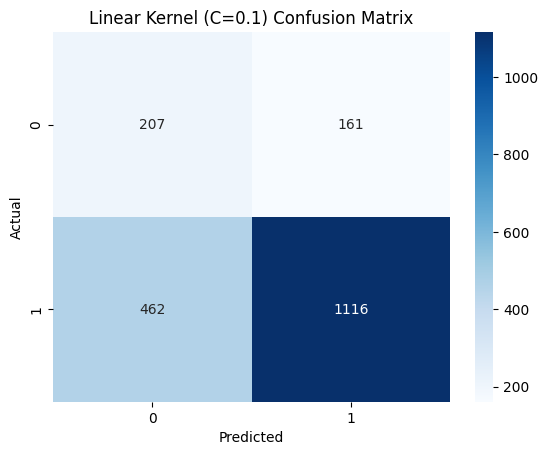

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Linear Kernel (C=0.1) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
linear2 = SVC(kernel='linear', C=0.5, random_state=42)
linear2.fit(x_train, y_train)
y_pred = linear2.predict(x_test)

print("Classification report of Linear Kernel (C=0.5)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of Linear Kernel (C=0.5)
              precision    recall  f1-score   support

           0       0.31      0.58      0.40       368
           1       0.88      0.70      0.78      1578

    accuracy                           0.68      1946
   macro avg       0.59      0.64      0.59      1946
weighted avg       0.77      0.68      0.71      1946


Accuracy: 0.6772867420349434


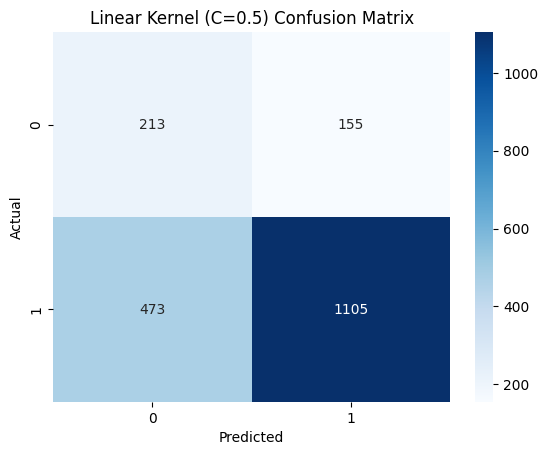

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Linear Kernel (C=0.5) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
linear3 = SVC(kernel='linear', C=0.3, random_state=42)
linear3.fit(x_train, y_train)
y_pred = linear3.predict(x_test)

print("Classification report of Linear Kernel (C=0.3)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of Linear Kernel (C=0.3)
              precision    recall  f1-score   support

           0       0.31      0.57      0.40       368
           1       0.88      0.71      0.78      1578

    accuracy                           0.68      1946
   macro avg       0.59      0.64      0.59      1946
weighted avg       0.77      0.68      0.71      1946


Accuracy: 0.6803699897225077


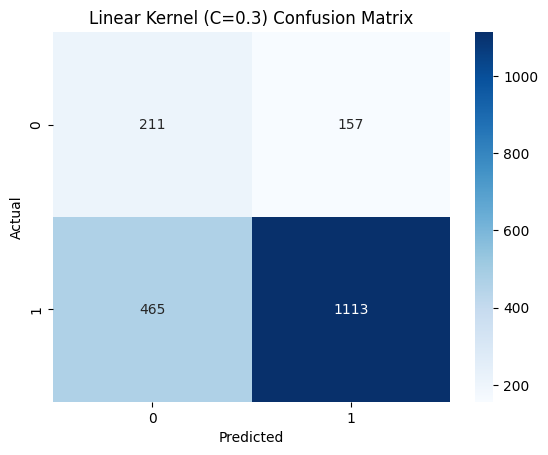

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Linear Kernel (C=0.3) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
linear3 = SVC(kernel='linear', C=0.001, random_state=42)
linear3.fit(x_train, y_train)
y_pred = linear3.predict(x_test)

print("Classification report of Linear Kernel (C=0.001)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of Linear Kernel (C=0.001)
              precision    recall  f1-score   support

           0       0.30      0.60      0.40       368
           1       0.88      0.67      0.76      1578

    accuracy                           0.66      1946
   macro avg       0.59      0.64      0.58      1946
weighted avg       0.77      0.66      0.69      1946


Accuracy: 0.6608427543679343


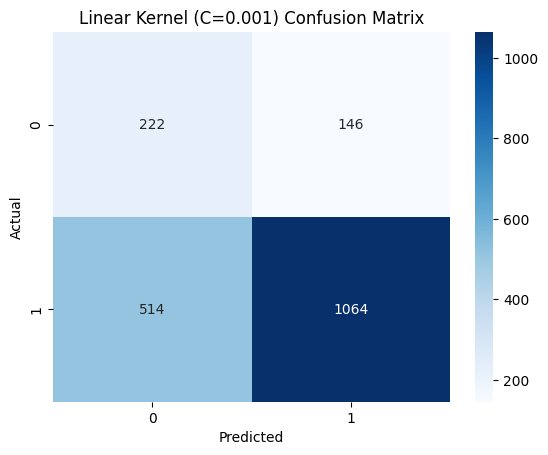

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Linear Kernel (C=0.001) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
linear3 = SVC(kernel='linear', C=0.01, random_state=42)
linear3.fit(x_train, y_train)
y_pred = linear3.predict(x_test)

print("Classification report of Linear Kernel (C=0.01)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Linear Kernel (C=0.01) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Polynomial Kernel

In [ ]:
poly1 = SVC(kernel='poly',degree=3,C=0.1, random_state=42)
poly1.fit(x_train, y_train)
y_pred = poly1.predict(x_test)

print("Classification report of Polynomial Kernel (C=0.1)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of Polynomial Kernel (C=0.1)
              precision    recall  f1-score   support

           0       0.19      0.89      0.31       368
           1       0.82      0.12      0.21      1578

    accuracy                           0.26      1946
   macro avg       0.50      0.50      0.26      1946
weighted avg       0.70      0.26      0.23      1946


Accuracy: 0.2641315519013361


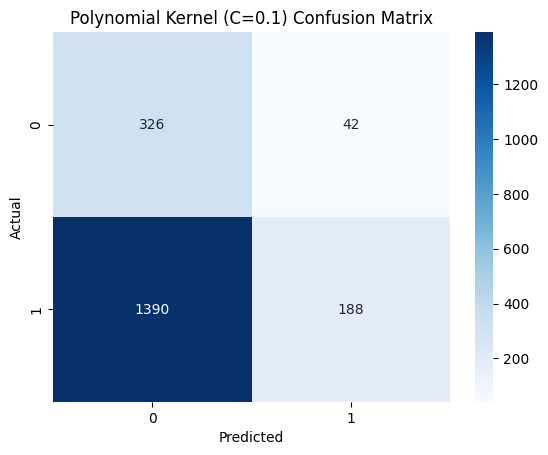

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Polynomial Kernel (C=0.1) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
poly2 = SVC(kernel='poly',degree=3,C=10, random_state=42)
poly2.fit(x_train, y_train)
y_pred = poly2.predict(x_test)

print("Classification report of Polynomial Kernel (C=10)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of Polynomial Kernel (C=10)
              precision    recall  f1-score   support

           0       0.19      0.88      0.32       368
           1       0.83      0.13      0.23      1578

    accuracy                           0.27      1946
   macro avg       0.51      0.51      0.27      1946
weighted avg       0.71      0.27      0.25      1946


Accuracy: 0.2749229188078109


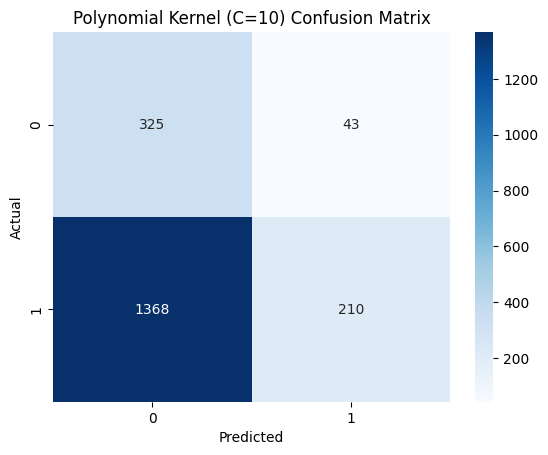

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Polynomial Kernel (C=10) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
poly2 = SVC(kernel='poly',degree=3,C=5, random_state=42)
poly2.fit(x_train, y_train)
y_pred = poly2.predict(x_test)

print("Classification report of Polynomial Kernel (C=5)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of Polynomial Kernel (C=5)
              precision    recall  f1-score   support

           0       0.19      0.88      0.31       368
           1       0.83      0.13      0.22      1578

    accuracy                           0.27      1946
   macro avg       0.51      0.51      0.27      1946
weighted avg       0.71      0.27      0.24      1946


Accuracy: 0.27183967112024665


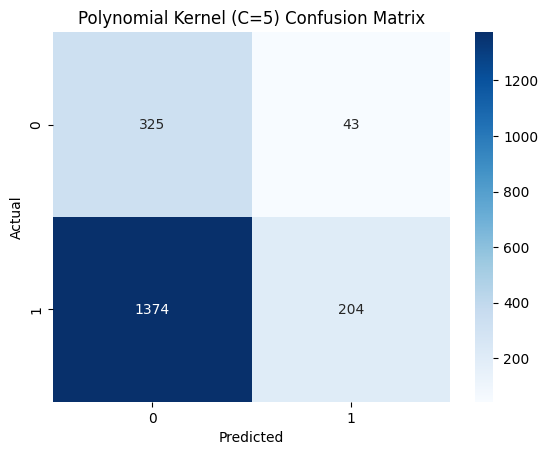

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Polynomial Kernel (C=5) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# RBF Kernel

In [ ]:
rbf1 = SVC(kernel='rbf',C=0.1)
rbf1.fit(x_train, y_train)
y_pred = rbf1.predict(x_test)

print("Classification report of RBF Kernel (C=0.1)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of RBF Kernel (C=0.1)
              precision    recall  f1-score   support

           0       0.20      0.55      0.29       368
           1       0.82      0.48      0.61      1578

    accuracy                           0.50      1946
   macro avg       0.51      0.52      0.45      1946
weighted avg       0.71      0.50      0.55      1946


Accuracy: 0.49743062692702983


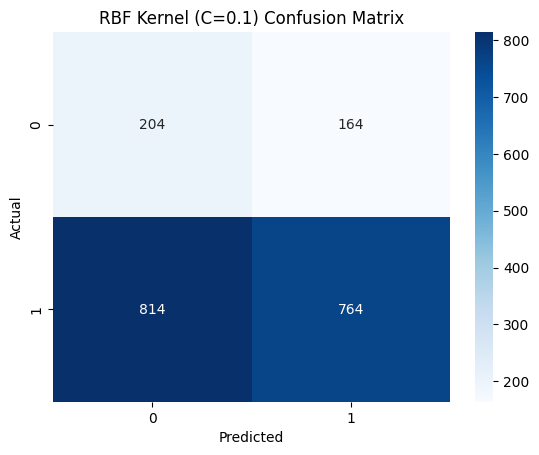

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('RBF Kernel (C=0.1) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
rbf2 = SVC(kernel='rbf',C=1)
rbf2.fit(x_train, y_train)
y_pred = rbf2.predict(x_test)

print("Classification report of RBF Kernel (C=1)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of RBF Kernel (C=1)
              precision    recall  f1-score   support

           0       0.20      0.61      0.31       368
           1       0.83      0.44      0.58      1578

    accuracy                           0.48      1946
   macro avg       0.52      0.53      0.44      1946
weighted avg       0.71      0.48      0.53      1946


Accuracy: 0.47533401849948614


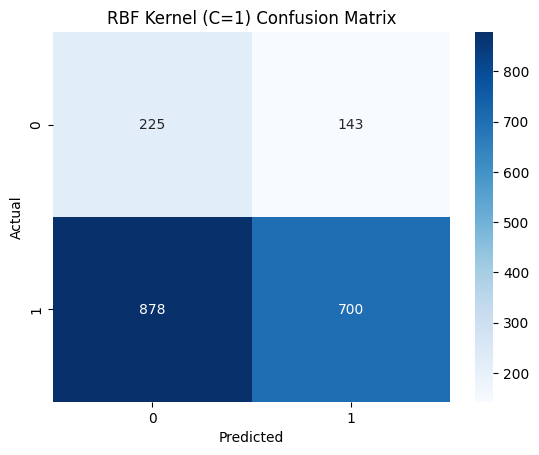

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('RBF Kernel (C=1) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
rbf3 = SVC(kernel='rbf',C=5)
rbf3.fit(x_train, y_train)
y_pred = rbf3.predict(x_test)

print("Classification report of RBF Kernel (C=5)")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Classification report of RBF Kernel (C=5)
              precision    recall  f1-score   support

           0       0.21      0.61      0.31       368
           1       0.84      0.47      0.60      1578

    accuracy                           0.49      1946
   macro avg       0.52      0.54      0.46      1946
weighted avg       0.72      0.49      0.54      1946


Accuracy: 0.4933196300102775


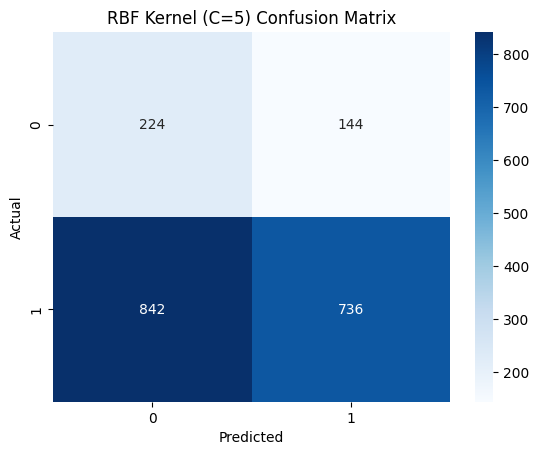

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('RBF Kernel (C=5) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

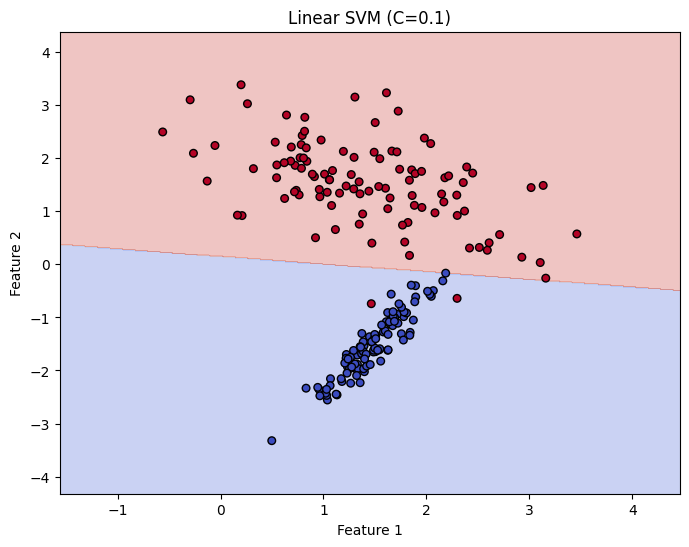

In [1]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Create synthetic dataset
X, y = datasets.make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Linear SVM
svm_model = SVC(kernel='linear', C=0.1)
svm_model.fit(X_train, y_train)

# Function to plot decision boundary
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(8,6))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot 1 - Default Linear SVM
plot_decision_boundary(svm_model, X_train, y_train, title="Linear SVM (C=0.1)")

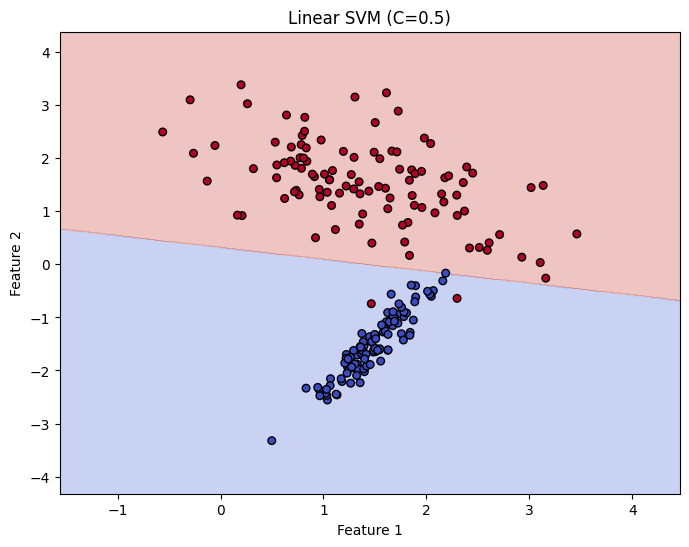

In [2]:
# Plot 2 - Different Regularization (C=0.5)
svm_model_lowC = SVC(kernel='linear', C=0.5)
svm_model_lowC.fit(X_train, y_train)
plot_decision_boundary(svm_model_lowC, X_train, y_train, title="Linear SVM (C=0.5)")

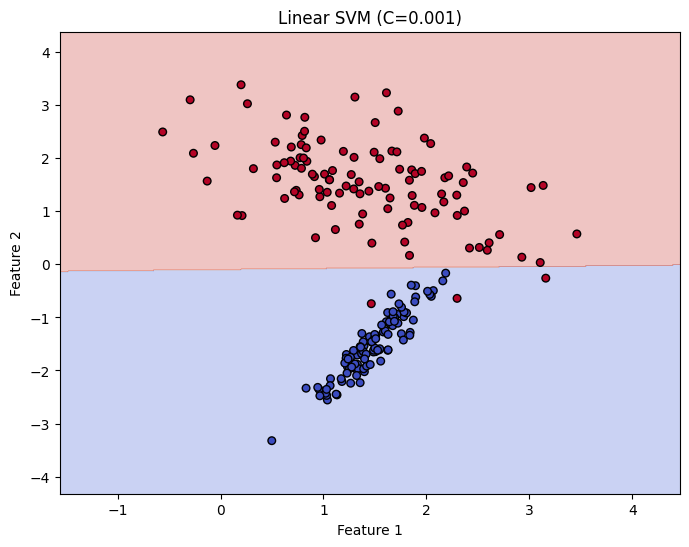

In [3]:
# Plot 3 - High Regularization (C=0.001)
svm_model_highC = SVC(kernel='linear', C=0.001)
svm_model_highC.fit(X_train, y_train)
plot_decision_boundary(svm_model_highC, X_train, y_train, title="Linear SVM (C=0.001)")

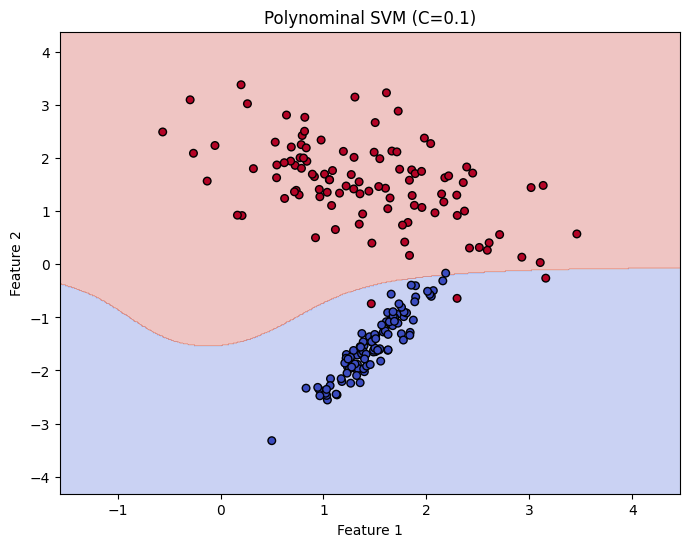

In [4]:
svm_model_highC = SVC(kernel='poly', C=0.1)
svm_model_highC.fit(X_train, y_train)
plot_decision_boundary(svm_model_highC, X_train, y_train, title="Polynominal SVM (C=0.1)")

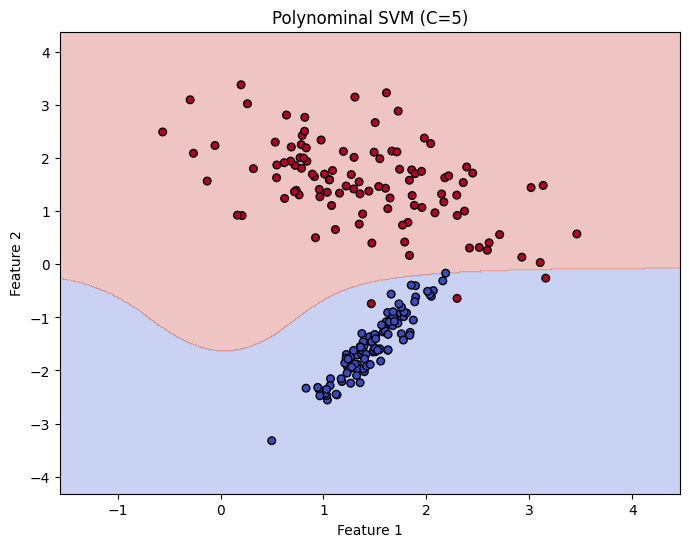

In [5]:
svm_model_highC = SVC(kernel='poly', C=5)
svm_model_highC.fit(X_train, y_train)
plot_decision_boundary(svm_model_highC, X_train, y_train, title="Polynominal SVM (C=5)")

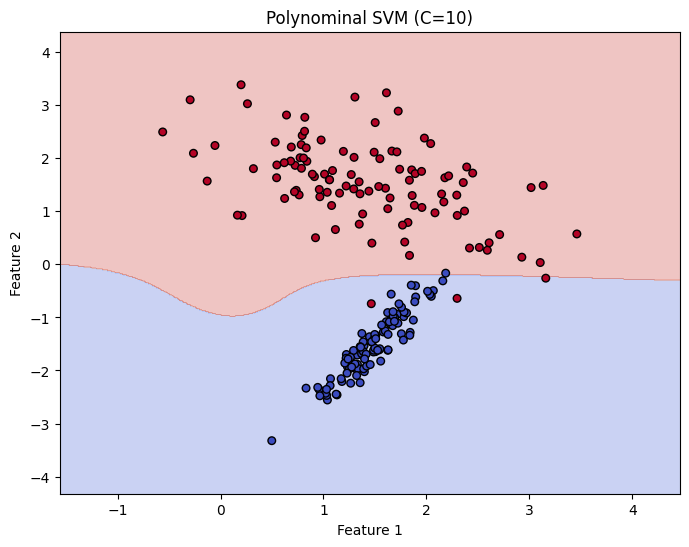

In [6]:
svm_model_highC = SVC(kernel='poly', C=10)
svm_model_highC.fit(X_train, y_train)
plot_decision_boundary(svm_model_highC, X_train, y_train, title="Polynominal SVM (C=10)")

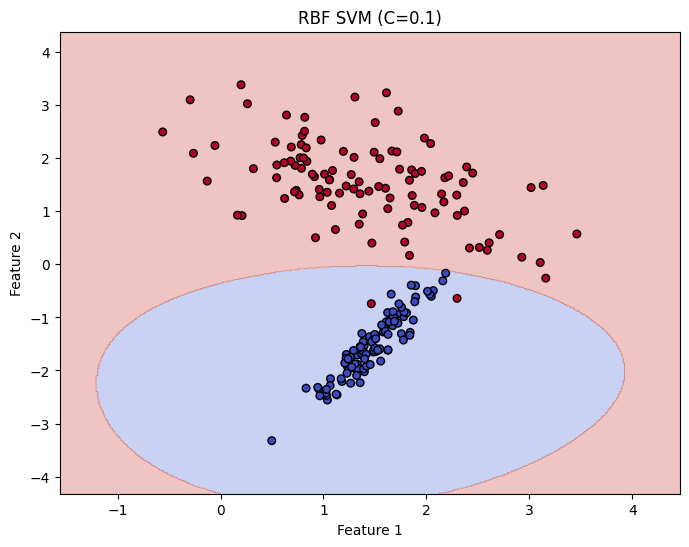

In [7]:
svm_model_highC = SVC(kernel='rbf', C=0.1)
svm_model_highC.fit(X_train, y_train)
plot_decision_boundary(svm_model_highC, X_train, y_train, title="RBF SVM (C=0.1)")

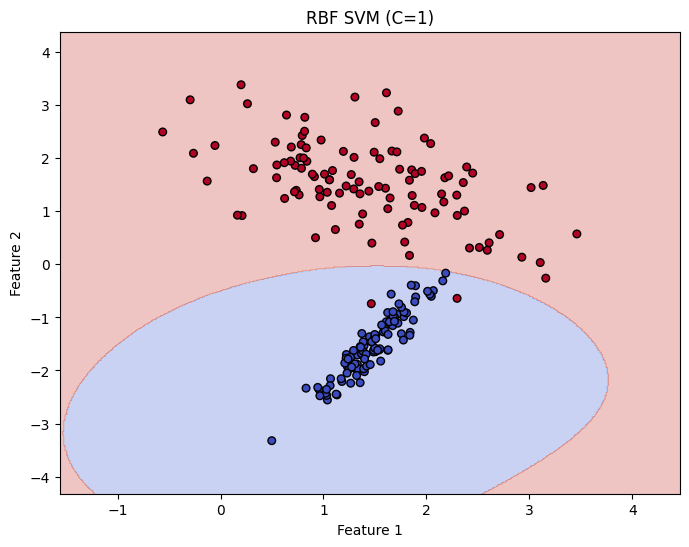

In [8]:
svm_model_highC = SVC(kernel='rbf', C=1)
svm_model_highC.fit(X_train, y_train)
plot_decision_boundary(svm_model_highC, X_train, y_train, title="RBF SVM (C=1)")

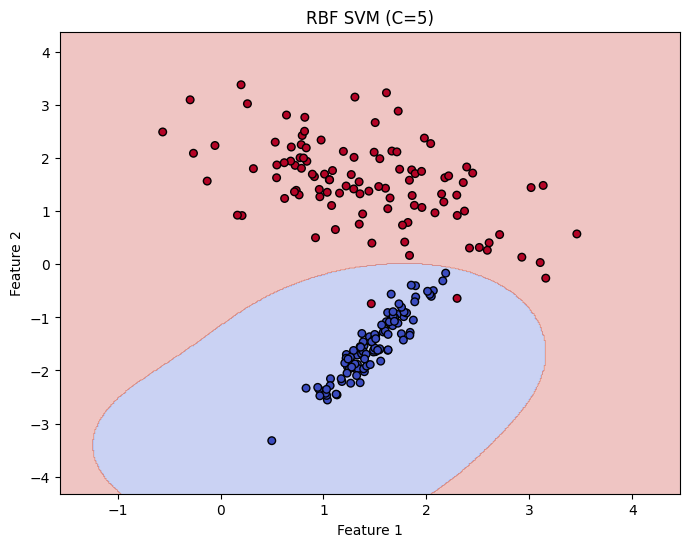

In [9]:
svm_model_highC = SVC(kernel='rbf', C=5)
svm_model_highC.fit(X_train, y_train)
plot_decision_boundary(svm_model_highC, X_train, y_train, title="RBF SVM (C=5)")

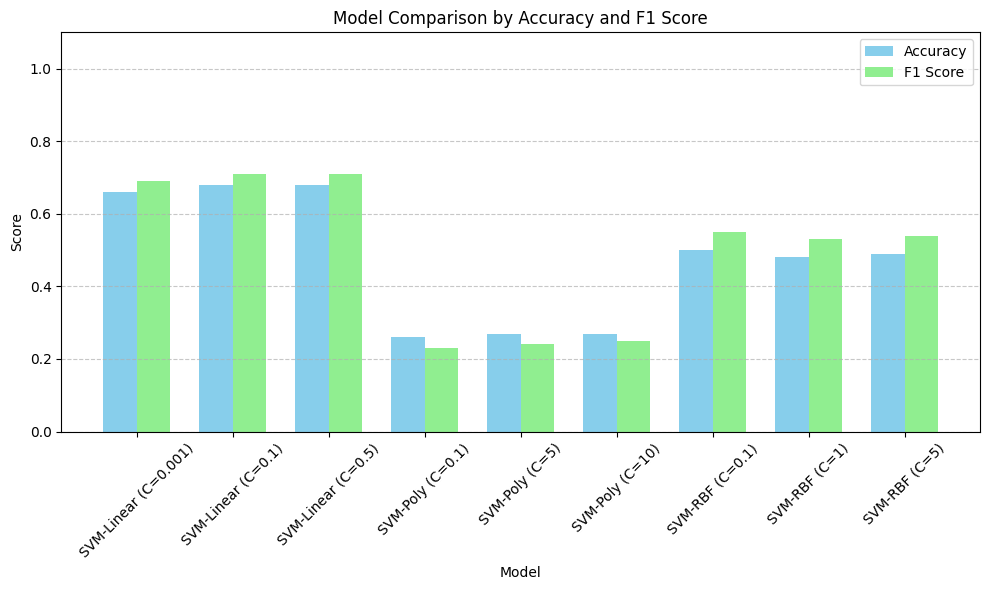

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define models and their scores
models = ['SVM-Linear (C=0.001)','SVM-Linear (C=0.1)','SVM-Linear (C=0.5)','SVM-Poly (C=0.1)', 'SVM-Poly (C=5)','SVM-Poly (C=10)','SVM-RBF (C=0.1)','SVM-RBF (C=1)','SVM-RBF (C=5)']
accuracy = [0.66, 0.68, 0.68, 0.26 , 0.27, 0.27, 0.50, 0.48, 0.49]
f1_score = [0.69, 0.71, 0.71, 0.23, 0.24, 0.25, 0.55, 0.53, 0.54]

# Bar width and positions
x = np.arange(len(models))
bar_width = 0.35

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, accuracy, width=bar_width, label='Accuracy',color='skyblue')
plt.bar(x + bar_width/2, f1_score, width=bar_width, label='F1 Score', color='lightgreen')

# Formatting
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Comparison by Accuracy and F1 Score')
plt.xticks(x, models, rotation=45)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
